## Problem Definition & Data Understanding

### 🔹Business Problem

E-news Express aims to improve online subscription by redesinging its landing page. The objective of this analysis is to evaluate whether the new landing page improves user engagement (time spent on page) and conversion rate compared to the existing page.

### 🔹Questions to Answer

- Do users spend more time on new page?
- Is conversion rate higher?
- Does conversion depend on language?
- Does time spent differ across languages?

### 🔹Data Description

|column_name|description|
|--|--|
|user_id | Unique visitor|
|group| control vs treatment|
|landing_page| new vs old|
|time_spent_on_the_page| Time (in minutes)|
|converted| become subscriber (yes/no)
|language_preferred | language|

### 🔹 Inital Checks

In [1]:
#Importing common libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
original_data = pd.read_csv('dataset/abtest.csv')

In [3]:
df = original_data.copy()

In [4]:
# Displaying the first 5 rows of the dataset
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [5]:
df.shape

(100, 6)

There are `100 rows` and `6 columns` in the dataset.

In [6]:
# Displaying the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


🔭**Observations:**

- User_id is an integer, and its based on the visitor

In [7]:
# Displaying the statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


In [8]:
# Checking for missing values in the dataset
df.isna().sum()

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

In [9]:
# Checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

> No missing values deducted. Dataset is ready for analysis

## Exploratory Data Analysis (EDA)

### 🔹Univariate Analysis

#### Categorical :

<Axes: xlabel='landing_page', ylabel='count'>

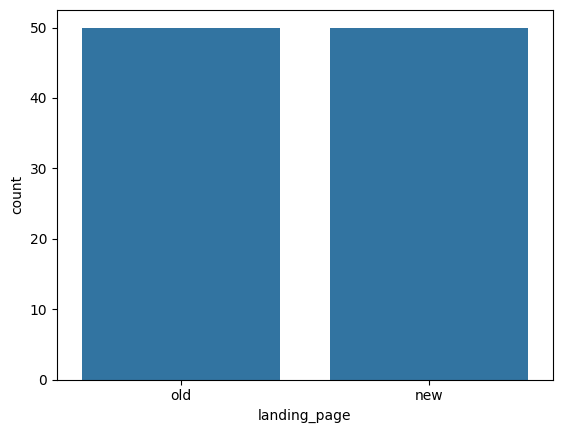

In [10]:
# Visualizing the distribution of the landing_page variable
sns.countplot(data=df, x='landing_page')

<Axes: xlabel='group', ylabel='count'>

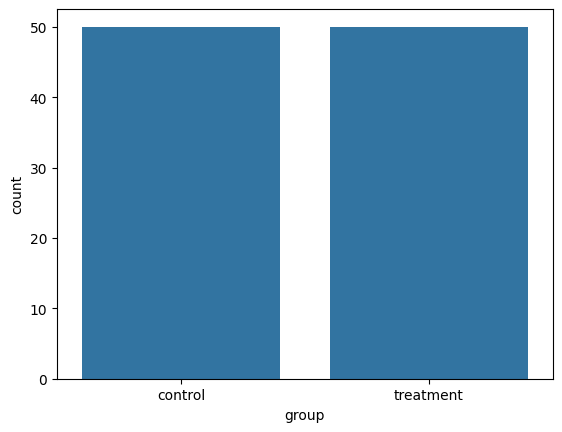

In [11]:
# Visualizing the distribution of the group variable
sns.countplot(data=df, x='group')

<Axes: xlabel='landing_page', ylabel='count'>

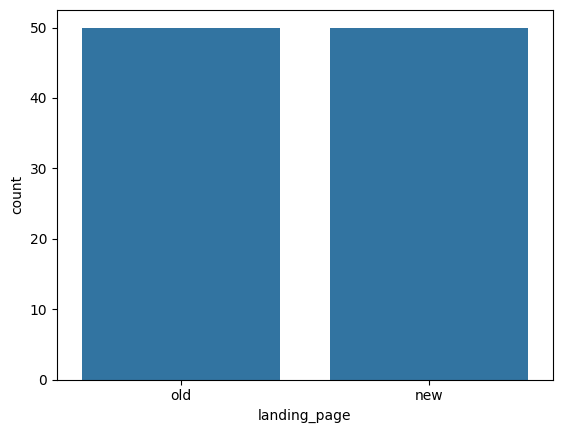

In [12]:
#visualizing the distribution of the landing page variable
sns.countplot(data=df, x='landing_page')

<Axes: xlabel='converted', ylabel='count'>

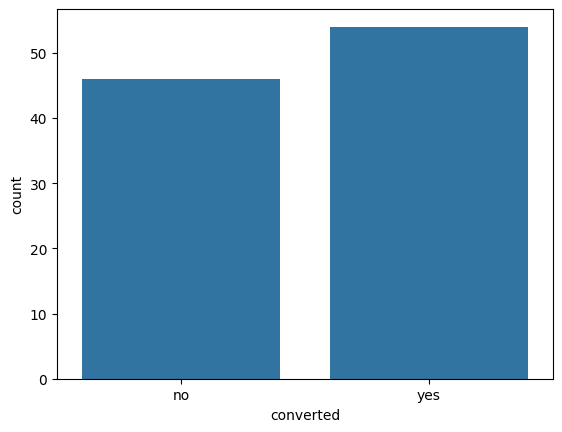

In [13]:
#visualizing the distribution of the converted variable
sns.countplot(data=df, x='converted')

<Axes: xlabel='language_preferred', ylabel='count'>

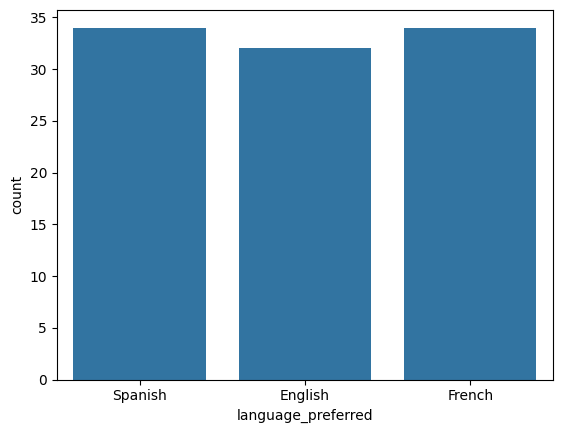

In [14]:
#visualizing the distribution of the language_preferred variable
sns.countplot(data=df, x='language_preferred')


#### Numerical:

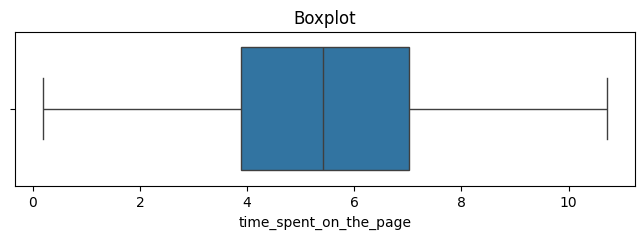

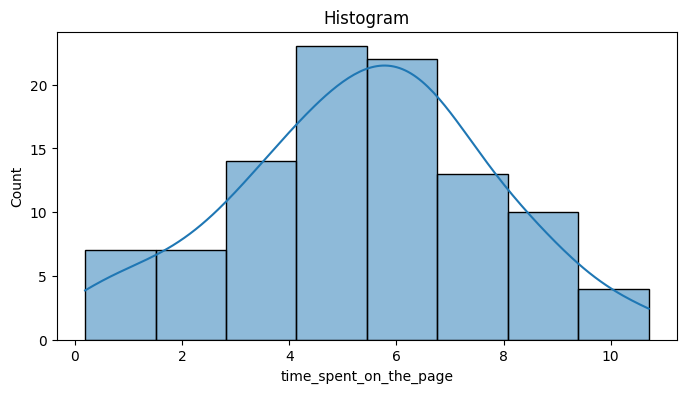

In [15]:
# Figure 1: boxplot
fig1, ax1 = plt.subplots(figsize=(8,2))
sns.boxplot(x=df['time_spent_on_the_page'], ax=ax1, color="C0")
ax1.set_title("Boxplot")

# Figure 2: histogram
fig2, ax2 = plt.subplots(figsize=(8,4))
sns.histplot(df['time_spent_on_the_page'], ax=ax2, kde=True, color="C0")
ax2.set_ylabel("Count")
ax2.set_title("Histogram")

plt.show()

>Distribution appears slightly right-skewed; presence of longer engagement sessions.

#### 🔹Bivariate Analysis

<Axes: xlabel='landing_page', ylabel='time_spent_on_the_page'>

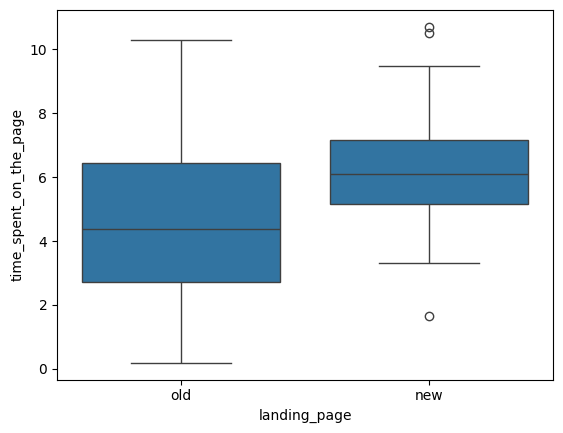

In [16]:
# Visualizing the relationship between landing_page and time_spent_on_the_page
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')

<Axes: xlabel='landing_page', ylabel='converted'>

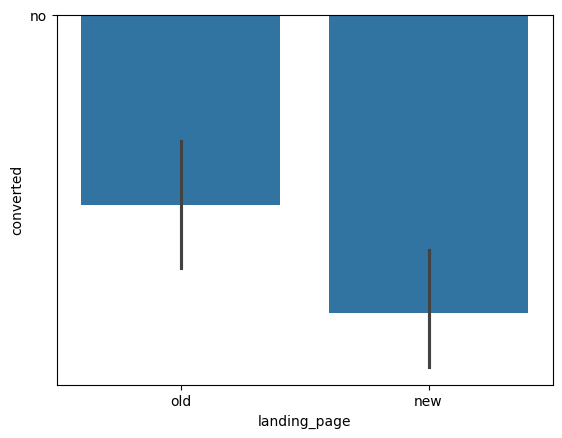

In [17]:
# Visualizing the relationship between landing_page and converted
sns.barplot(data=df, x='landing_page', y='converted')


<Axes: xlabel='language_preferred', ylabel='time_spent_on_the_page'>

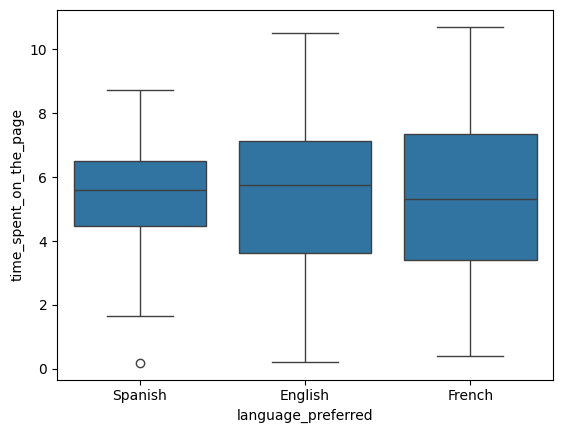

In [18]:
# Visualizing the relationship between language_preferred and time_spent_on_the_page
sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')


<Axes: xlabel='language_preferred', ylabel='count'>

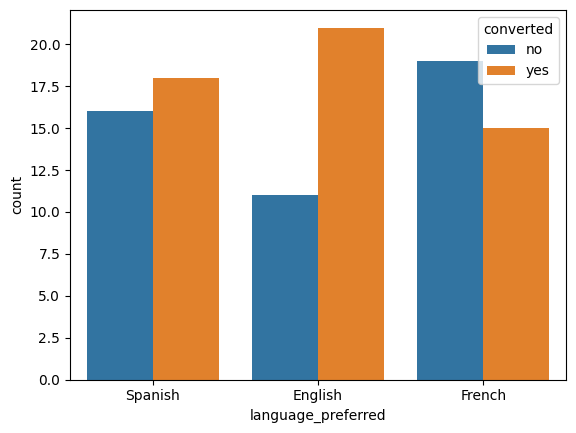

In [19]:
# Visualizing the relationship between language_preferred and converted
sns.countplot(data=df, x='language_preferred', hue='converted')


### 🔹Hypothesis Testing

#### Q1: Do users spend more time on the new landing page?

##### Visual Depiction from EDA


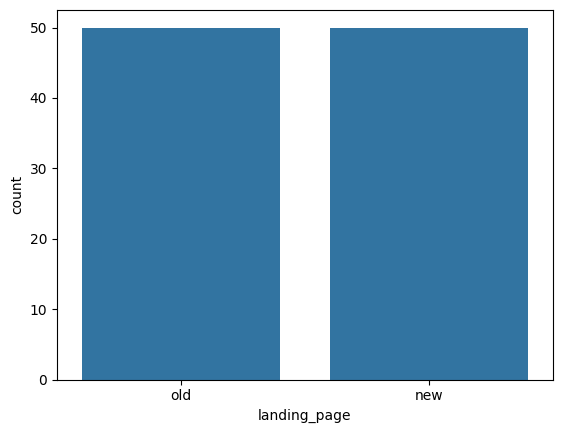

##### Hypothesis

> H0 : $\mu$\_new $\le$ $\mu$\_old

> H1 : $\mu$\_new = $\mu$\_old

##### Test Selection

> Independent Samples t-test is appropriate because
>- Comparing means of two independent group
>- Numeric dependent variable
>- Random assignment ensures independence
>

##### Data Preparation

In [20]:
old = df[df['landing_page']=='old']['time_spent_on_the_page']
new = df[df['landing_page']=='new']['time_spent_on_the_page']

In [21]:
#Data Preparation

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(new, old, alternative='greater')

##### Inference

In [22]:
print (f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 3.7867702694199856, P-value: 0.0001316123528095005


> Since the p value is less than 0.05, we reject the null Hypothesis. There is statistically significant evidence that users spend more time on the new landing page.

✅ Conclusion: The new page improves subscriber acquisition.

#### Q2: Is conversion rate higher for new page?

Test : 2 proportion z-test

> H0 : $\mu$\_new $\le$ $\mu$\_old

> H1 : $\mu$\_new $\gt$ $\mu$\_old

In [34]:
from statsmodels.stats.proportion import proportions_ztest

In [35]:
# Count conversions per landing page
conversion_counts = df.groupby('landing_page')['converted'].apply(lambda x: (x == 'yes').sum())
total_counts = df.groupby('landing_page')['converted'].count()

In [36]:
# Perform one-tailed Z-test (new > old)
z_stat, p_value = proportions_ztest(
    conversion_counts,
    total_counts,
    alternative='larger'
)


In [37]:
print("Two-Proportion Z-Test")
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Two-Proportion Z-Test
Z-statistic: 2.4077170617153842
P-value: 0.008026308204056278


Since p-value < 0.05, we reject the null hypothesis.

There is statistically significant evidence that the conversion rate for the new landing page is higher than the old page.

✅ Conclusion: The new page improves subscriber acquisition.

#### Q3: Does conversion depend on language?

Test: Chi-Square Test of Independence

H0: Conversion and language are independent

H1: They are associated

In [24]:
from scipy.stats import chi2_contingency

In [25]:
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])


In [26]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)


In [27]:
print("Chi-Square Test of Independence")
print("Chi-square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

Chi-Square Test of Independence
Chi-square Statistic: 3.0930306905370832
Degrees of Freedom: 2
P-value: 0.2129888748754345


Since p-value > 0.05, we fail to reject the null hypothesis.

There is no statistically significant association between language preference and conversion status.

✅ Conclusion: Conversion is independent of language.

#### Q4: Is mean time spent same across languages?

Test: One-Way ANOVA

H0: All means are equal

H1: At least one mean differs

In [28]:
from scipy.stats import f_oneway


In [29]:
languages = df['language_preferred'].unique()

In [30]:
groups = [
    df[df['language_preferred'] == lang]['time_spent_on_the_page']
    for lang in languages
]

In [31]:
f_stat, p_value = f_oneway(*groups)

In [32]:
print("One-Way ANOVA")
print("F-statistic:", f_stat)
print("P-value:", p_value)

One-Way ANOVA
F-statistic: 0.1434343922124043
P-value: 0.8665610536012648


Since p-value > 0.05, we fail to reject the null hypothesis.

There is no statistically significant difference in mean time spent across different language groups.

✅ Conclusion: Engagement time does not vary by language.

## Conclusion

This analysis evaluated the redesigned landing page using statistical hypothesis testing at a 5% significance level.

The results provide strong evidence that the new landing page significantly improves both user engagement and conversion rate. Users spend more time on the new page, and the probability of conversion is statistically higher compared to the old design.

No statistically significant relationship was found between language preference and conversion status. Similarly, time spent on the page does not vary meaningfully across language groups.

The evidence therefore isolates the landing page design itself — rather than language segmentation — as the primary driver of improved performance.

## Business Recommendations

🔹 Priority 1: Full Deployment of the New Landing Page

The most immediate and highest-impact action is to replace the old landing page with the new version. Statistical testing confirms measurable improvements in both engagement and subscriber conversion, directly impacting revenue growth.

🔹 Priority 2: Focus Optimization Efforts on Page Design, Not Language Segmentation

Since language preference does not significantly influence engagement or conversion, allocating resources toward language-specific redesign would not yield meaningful returns at this stage. Efforts should instead concentrate on refining layout, content hierarchy, and call-to-action placement.

🔹 Priority 3: Implement Continuous Experimentation Framework

While the current redesign is successful, sustained growth requires structured experimentation. Future A/B tests should target:

CTA positioning and wording

Content personalization

Visual engagement elements

Subscription incentives

A systematic experimentation roadmap will ensure ongoing performance improvement.

🔹 Priority 4: Monitor Engagement as a Leading Indicator

Time spent on the page significantly increased alongside conversion rates. Engagement should therefore be tracked as a key leading metric in future optimization strategies.

## Executive Summary

The redesigned landing page demonstrates statistically significant improvements in both user engagement and conversion performance. The primary performance driver is page design rather than language preference. Immediate deployment is recommended, supported by a structured experimentation strategy to sustain long-term growth.